# 01 — EDA and Cleaning

This notebook is the first stop in the sneaker resale price estimator project. It looks at the
**raw** data exactly as it arrives from StockX, points out the quirks that make it unsafe to feed
directly into a model, and then calls the real `sneakerml.data.clean` pipeline (not a hand-rolled
copy of it) to produce the cleaned dataset the rest of the project builds on.

Everything here is computed live against the actual files checked into this repo
(`backend/data/raw/stockx_2019.csv`, `backend/data/processed/clean_report.json`, ...) — no numbers
are hand-typed from documentation.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sneakerml.config import RAW_DIR, PROCESSED_DIR
from sneakerml.data import clean

pd.set_option("display.max_columns", 20)
RAW_DIR, PROCESSED_DIR

(PosixPath('/Users/User/ml sneaker proj/ml-sneaker-resale-price-estimator/backend/data/raw'),
 PosixPath('/Users/User/ml sneaker proj/ml-sneaker-resale-price-estimator/backend/data/processed'))

## 1. The raw StockX CSV, warts and all

We load this with plain `pandas.read_csv` — deliberately *not* through `sneakerml` — so we can see
the file the way it actually looks before anyone touches it.

In [2]:
raw_path = RAW_DIR / "stockx_2019.csv"
raw = pd.read_csv(raw_path)
print(f"{len(raw):,} rows")
raw.head(3)

99,956 rows


,Order Date,Brand,Sneaker Name,Sale Price,Retail Price,Release Date,Shoe Size,Buyer Region,Days Since,Profit
0,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-Low-V2-Beluga,1097,220,9/24/16,11.0,California,342,877
1,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Copper,685,220,11/23/16,11.0,California,282,465
2,9/1/17,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Green,690,220,11/23/16,11.0,California,282,470


### The BOM / leading-space quirk

Look closely at the `Brand` column's unique values below — StockX's export has a **leading space**
on some brand names (`" Yeezy"` instead of `"Yeezy"`). If you don't strip it, `" Yeezy"` and any
future clean `"Yeezy"` value become two different categories to a one-hot encoder.

In [3]:
print(raw.columns.tolist())
print(raw["Brand"].unique())

['Order Date', 'Brand', 'Sneaker Name', 'Sale Price', 'Retail Price', 'Release Date', 'Shoe Size', 'Buyer Region', 'Days Since', 'Profit']
<ArrowStringArray>
[' Yeezy', 'Off-White']
Length: 2, dtype: str


### Dates are strings, not datetimes

`Order Date` and `Release Date` come in as `M/D/YY` strings. Any date arithmetic (e.g.
`days_since_release`) needs an explicit parse first — pandas will not do it for you.

In [4]:
print(raw["Order Date"].dtype, raw["Release Date"].dtype)
raw[["Order Date", "Release Date"]].head(3)

str str


,Order Date,Release Date
0,9/1/17,9/24/16
1,9/1/17,11/23/16
2,9/1/17,11/23/16


### `Days Since` and `Profit` are leakage columns

Both columns are visible in the raw file:

In [5]:
print("Days Since" in raw.columns, "Profit" in raw.columns)
raw[["Sale Price", "Retail Price", "Profit", "Days Since"]].head(3)

True True


,Sale Price,Retail Price,Profit,Days Since
0,1097,220,877,342
1,685,220,465,282
2,690,220,470,282


`Profit` is `Sale Price - Retail Price` computed *after* the sale — i.e. it's a deterministic
function of the target we're trying to predict. `Days Since` is "days since [some reference date],"
computed after the fact from the same order date used to build the training/test split. Feeding
either into the model would let it see (or trivially reconstruct) information that is only
available in hindsight — classic target leakage. `sneakerml.data.clean.load_stockx` drops both
columns unconditionally.

## 2. Cleaning with the real pipeline

Now we call the actual `sneakerml.data.clean` functions, step by step, instead of re-deriving
their logic here.

In [6]:
stockx = clean.load_stockx(RAW_DIR / "stockx_2019.csv")
print(stockx.shape)
stockx.dtypes

(99956, 10)


order_date      datetime64[us]
brand                      str
sneaker_name               str
slug                       str
sale_price             float64
retail_price           float64
release_date    datetime64[us]
shoe_size              float64
buyer_region               str
source                     str
dtype: object

In [7]:
listings = clean.load_listings(RAW_DIR / "listings_sim.csv", stockx_path=RAW_DIR / "stockx_2019.csv")
print("stockx:", len(stockx), " listings:", len(listings))
listings.head(3)

stockx: 99956  listings: 22000


,order_date,brand,sneaker_name,slug,sale_price,retail_price,release_date,shoe_size,buyer_region,source
0,2018-08-02,Yeezy,Adidas-Yeezy-Boost-350-V2-Butter,adidas-yeezy-boost-350-v2-butter,271.00,220.0,2018-06-30,12.0,NaN,goatish
1,2018-05-29,Off-White,Air-Jordan-1-Retro-High-Off-White-University-Blue,air-jordan-1-retro-high-off-white-university-blue,1124.47,190.0,2018-06-23,NaN,NaN,goatish
2,2018-11-29,Off-White,Nike-Blazer-Mid-Off-White-Grim-Reaper,nike-blazer-mid-off-white-grim-reaper,450.00,130.0,2018-10-03,13.0,NaN,goatish


In [8]:
combined = pd.concat([stockx, listings], ignore_index=True)
combined, dedupe_report = clean.dedupe(combined)
dedupe_report

{'rows_before_dedupe': 121956,
 'within_source_dupes_removed': 19102,
 'within_source_dupes_removed_by_source': {'stockx': 16206, 'goatish': 2896},
 'cross_source_dupes_removed': 11910,
 'rows_after_dedupe': 90944}

In [9]:
combined = clean.impute_size(combined)
sizes_imputed = int(combined["size_imputed"].sum())
sizes_imputed

380

## 3. Before / after row counts, from the real cleaning report

Rather than re-deriving these totals ourselves, we load the `clean_report.json` that
`build_clean_dataset` actually wrote to disk when the shipped `clean.parquet` was produced.

In [10]:
report = json.loads((PROCESSED_DIR / "clean_report.json").read_text())
report

{'rows_in': 121956,
 'rows_out': 90944,
 'dropped_unmatched_slugs': 0,
 'within_source_dupes_removed': 19102,
 'within_source_dupes_removed_by_source': {'stockx': 16206, 'goatish': 2896},
 'cross_source_dupes_removed': 11910,
 'sizes_imputed': 380,
 'invalid_price_rows_filtered': 0}

In [11]:
print(f"rows in (stockx + listings, pre-merge):  {report['rows_in']:,}")
print(f"rows out (final clean.parquet):             {report['rows_out']:,}")
print(f"  dropped (unmatched slugs):                {report['dropped_unmatched_slugs']:,}")
print(f"  within-source dupes removed (total):      {report['within_source_dupes_removed']:,}")
for source, n in report['within_source_dupes_removed_by_source'].items():
    print(f"    - {source}: {n:,}")
print(f"  cross-source dupes removed:                {report['cross_source_dupes_removed']:,}")
print(f"  sizes imputed:                             {report['sizes_imputed']:,}")
print(f"  invalid-price rows filtered:               {report['invalid_price_rows_filtered']:,}")

rows in (stockx + listings, pre-merge):  121,956
rows out (final clean.parquet):             90,944
  dropped (unmatched slugs):                0
  within-source dupes removed (total):      19,102
    - stockx: 16,206
    - goatish: 2,896
  cross-source dupes removed:                11,910
  sizes imputed:                             380
  invalid-price rows filtered:               0


### Why the within-source count is broken down by source

A single combined `within_source_dupes_removed` number invites the wrong story: "the scraper produced
a bunch of duplicate rows." Broken down by source, the real picture is very different --
most of the within-source count on the **real StockX side** is genuine repeat sales of popular shoes
(two different people buying the same shoe, in the same size, on the same day, at the same price --
unsurprising for a high-volume item with thousands of sales over 18 months), not scrape noise.
The **simulated ("goatish") side** is where deliberately duplicated rows actually live
(`simulate.DUPLICATE_FRACTION`), so its count is the one that should be read as "artifacts caught."

## 4. Load the real shipped clean dataset

Rather than re-running `build_clean_dataset` (which would overwrite the shipped artifact), we load
the `clean.parquet` that's already checked into `backend/data/processed/` for the distribution plot
below — this is the exact dataset every other notebook and the trained model builds on.

In [12]:
clean_df = pd.read_parquet(PROCESSED_DIR / "clean.parquet")
print(clean_df.shape)
clean_df.head(3)

(90944, 11)


,order_date,brand,sneaker_name,slug,sale_price,retail_price,release_date,shoe_size,buyer_region,source,size_imputed
0,2017-09-07,Yeezy,Adidas-Yeezy-Boost-350-Low-Moonrock,adidas-yeezy-boost-350-low-moonrock,1230.0,200.0,2015-11-14,10.5,Michigan,stockx,False
1,2017-09-26,Yeezy,Adidas-Yeezy-Boost-350-Low-Moonrock,adidas-yeezy-boost-350-low-moonrock,1257.0,200.0,2015-11-14,9.5,Nevada,stockx,False
2,2017-10-04,Yeezy,Adidas-Yeezy-Boost-350-Low-Moonrock,adidas-yeezy-boost-350-low-moonrock,1000.0,200.0,2015-11-14,7.0,California,stockx,False


## 5. Price distribution: raw vs. log1p

Resale sneaker prices are heavily right-skewed: most sales cluster in the low hundreds of dollars,
but a long tail of hype releases sells for thousands. A handful of outliers can dominate a
squared-error loss and distort a linear model's coefficients. Taking `log1p(price)` compresses that
tail, makes the distribution far closer to symmetric/normal, and turns multiplicative price effects
(e.g. "this colorway roughly doubles the price") into additive ones in log-space — which is exactly
why `sneakerml.train` fits its models on `log1p(sale_price)` rather than raw dollars.

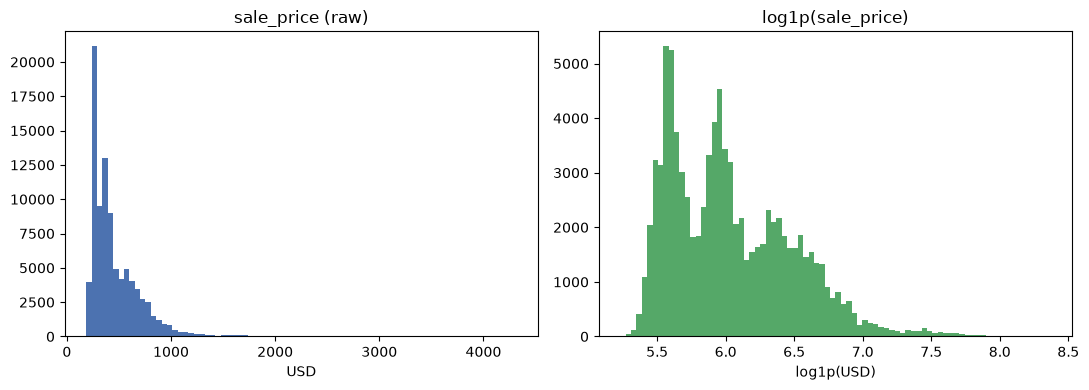

raw skewness:       2.9061673802833234
log1p skewness:      0.8254370759395723


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(clean_df["sale_price"], bins=80, color="#4C72B0")
axes[0].set_title("sale_price (raw)")
axes[0].set_xlabel("USD")

axes[1].hist(np.log1p(clean_df["sale_price"]), bins=80, color="#55A868")
axes[1].set_title("log1p(sale_price)")
axes[1].set_xlabel("log1p(USD)")

fig.tight_layout()
plt.show()

print("raw skewness:      ", clean_df["sale_price"].skew())
print("log1p skewness:     ", np.log1p(clean_df["sale_price"]).skew())

## Summary

- The raw StockX CSV has a leading-space quirk in `Brand`, string dates, and two leakage columns
  (`Days Since`, `Profit`) that must be dropped before modelling.
- `sneakerml.data.clean` reverses the simulated "goatish" marketplace's dirtying transforms, merges
  it with StockX on a normalized slug, dedupes within- and cross-source duplicates, and imputes
  missing sizes per-shoe.
- The real cleaning run went from **121,956 rows in** to **90,944 rows out**.
- Sale price is right-skewed; a `log1p` transform makes it far better-behaved for the quantile GBM
  models trained in notebook 03.